# M1.Ex1: Model Hours vs Marks

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex1_reg.ipynb)
- Raw Dataset: [Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv)

In [ ]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error






### Step 1. Load the data

In [4]:
# pd.read_csv("../../../datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv").head()

In [5]:
df=pd.read_csv("../../content/datasets/Rounded_Student_Hours_Studied_vs_Marks_Dataset.csv")
df.head()

,Hours_Studied,Marks
0,4.76,46.27
1,3.00,34.30
2,2.08,33.63
3,4.04,47.81
4,9.49,66.26


### Step 2.a Assign variables `X` to the features and `y` to the target

In [6]:
features = 'Hours_Studied'
target = 'Marks'
data = df[[features]]
target = df[target]


### Step 2.b print the type of each

In [7]:
data.shape , target.shape

((100, 1), (100,))

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [8]:
df.info()
#the target variable is numeric and the feature variable is also numeric
#and the task is regression

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  100 non-null    float64
 1   Marks          100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [ ]:
#samples hours studied 100 
#columns 1
#target marks  100 samples 
#columns 0 

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
df.describe()

,Hours_Studied,Marks
count,100.000000,100.000000
mean,5.376300,46.360200
std,2.593013,14.284805
min,1.050000,20.190000
25%,3.175000,33.675000
50%,5.565000,47.485000
75%,7.255000,57.377500
max,9.870000,73.260000


### Step 5. Plot the feature vs the target

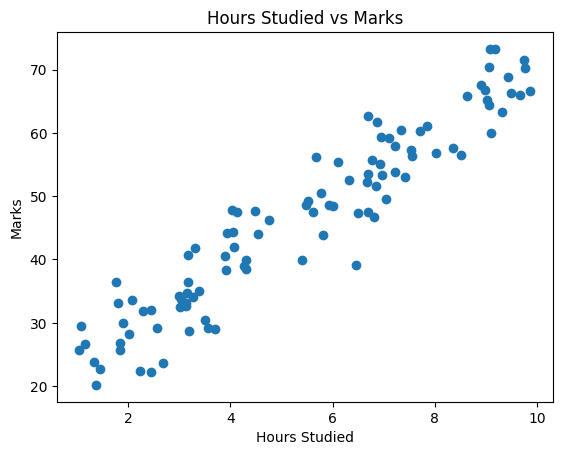

In [10]:
plt.scatter(data, target)
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Hours Studied vs Marks')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [11]:
#he hours studied will increase the marks

### Step 7. Initialize a `LinearRegression` model

In [12]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [20]:
X_train, x_test, y_train, y_test = train_test_split(
    data, target,
     test_size=0.2, 
     random_state=42 
     
     )


### Step 9.a Train the model on the training set

In [14]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the model

In [15]:
slope = model.coef_
print("Slope:", slope)


Slope: [5.16443841]


### Step 9.c how much marks do we get per 1 hour of study?

In [38]:
hour_increase = slope[0]
print(" 1 hour increase in study time:", f"{hour_increase:.2f} marks ")

 1 hour increase in study time: 5.16 marks 


### Step 9.d how much does a 10 minutes increase of study time adds to our marks?

In [17]:
increase_10=slope*10
print(increase_10)

[51.64438413]


### Step 9.e if one doesn't study at all, how much marks do they get?

In [40]:
pre=model.predict(np.array([[0]]))
print("Predicted marks for 0 hours studied:", f"{pre[0]:.2f}")

Predicted marks for 0 hours studied: 18.54


/Users/mafahad/Desktop/ai sdaia/B5/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 10. Evaluate the model on the test set

In [31]:

train_mse = mean_squared_error(y_train, model.predict(X_train))
test_mse = mean_squared_error(y_test, model.predict(x_test))

print(train_mse, test_mse)

21.467365969453443 14.731128407667569


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [28]:
x_sample =x_test.sample(3, random_state=42)
y_sample = model.predict(x_sample)

comparison = pd.DataFrame({
    'Actual': y_test.loc[x_sample.index],
    'Predicted': y_sample   
})  
print(comparison)

    Actual  Predicted
83   32.50  34.135183
77   53.36  54.534714
4    66.26  67.549099


### Step 12. Plot the data and the regression line

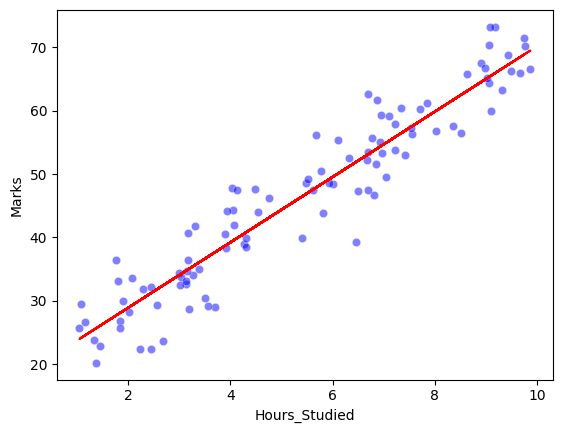

In [30]:
sns.scatterplot(
    x=data['Hours_Studied'], 
    y=target, 
    color='blue',
    alpha=0.5
)
plt.plot(
    data['Hours_Studied'], 
    model.predict(data), 
    color='red'
)